# POC SOC Triage — 04 XAI (Explainability)

**Objectif** : générer les explications XAI pour chaque incident — ce que verra l'analyste N1.

- **SHAP global** : quelles features comptent le plus pour le modèle ?
- **SHAP local** : pourquoi cet incident a-t-il ce score ?
- **Counterfactual** : qu'est-ce qui aurait changé la décision ?

**Output** : `shap_values_sample.pkl` + figures d'explication


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from pathlib import Path

DATA_DIR = Path('data')
MODEL_DIR = Path('models')

print(f'SHAP version: {shap.__version__}')

SHAP version: 0.46.0


In [14]:
# Chargement du modèle et des données
xgb_model = joblib.load(MODEL_DIR / 'xgboost_model.pkl')
df_feat    = pd.read_parquet(DATA_DIR / 'features_ml.parquet')   # ← parquet
df_pred    = pd.read_csv(DATA_DIR / 'predictions_sample.csv')
# incidents_aggregated.csv supprimé — plus utilisé ici

# FEATURE_COLS doit être identique à celui du 03 (exclure OrgId aussi)
FEATURE_COLS = [c for c in df_feat.columns if c not in ['IncidentId', 'target', 'OrgId']]

df_sample = df_feat[df_feat['IncidentId'].isin(df_pred['IncidentId'])].copy()
df_sample = df_sample.merge(df_pred[['IncidentId', 'priority_score', 'decision_suggested',
                                      'severity', 'grade_reel_label']], on='IncidentId')
df_sample = df_sample.reset_index(drop=True)
X_sample  = df_sample[FEATURE_COLS].values

print(f'df_feat: {len(df_feat):,} | df_pred: {len(df_pred):,} | matched: {len(df_sample):,}')
if len(df_sample) < len(df_pred):
    print(f'WARNING: {len(df_pred) - len(df_sample)} predictions ont des features manquantes.')
print(f'Features : {len(FEATURE_COLS)}')

assert X_sample.shape[1] == xgb_model.n_features_in_, \
    f"Feature mismatch: {X_sample.shape[1]} vs {xgb_model.n_features_in_} attendues"

df_feat: 30,000 | df_pred: 500 | matched: 500
Features : 55


## 1. SHAP — Calcul des valeurs

In [15]:
print('Calcul des SHAP values (TreeExplainer — rapide pour XGBoost)...')
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)  # shape: (3, n_samples, n_features)
# shap_values[0] = FP, shap_values[1] = BP, shap_values[2] = TP

print(f'SHAP values calculées :')
print(f'  Forme : {len(shap_values)} classes × {shap_values[0].shape}')

# Sauvegarde pour la démo Streamlit
joblib.dump({
    'shap_values': shap_values,   # ← toujours liste de 3 arrays après normalisation
    'feature_names': FEATURE_COLS,
    'X_sample': X_sample,
    'incident_ids': df_sample['IncidentId'].values
}, DATA_DIR / 'shap_values_sample.pkl')
print('Sauvegardé : shap_values_sample.pkl')

Calcul des SHAP values (TreeExplainer — rapide pour XGBoost)...
SHAP values calculées :
  Forme : 500 classes × (55, 3)
Sauvegardé : shap_values_sample.pkl


In [16]:
# normalisation des SHAP values pour compatibilité avec différentes versions de SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values_raw = explainer.shap_values(X_sample)

# Normalisation : gère les deux formats selon la version de SHAP
if isinstance(shap_values_raw, list):
    # Ancienne API : liste de 3 arrays (n_samples, n_features)
    shap_values = shap_values_raw  # shap_values[0]=FP, [1]=BP, [2]=TP
    print(f'Format SHAP : liste de {len(shap_values)} arrays {shap_values[0].shape}')
else:
    # Nouvelle API : array 3D (n_samples, n_features, n_classes)
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    print(f'Format SHAP : array 3D converti en liste de {len(shap_values)} arrays {shap_values[0].shape}')

# shap_values[0]=FP, shap_values[1]=BP, shap_values[2]=TP — cohérent dans les deux cas
shap_tp = shap_values[2]
print(f'shap_tp shape : {shap_tp.shape}  (attendu : {X_sample.shape})')

Format SHAP : array 3D converti en liste de 3 arrays (500, 55)
shap_tp shape : (500, 55)  (attendu : (500, 55))


## 2. SHAP global — Importance des features pour la classe TP

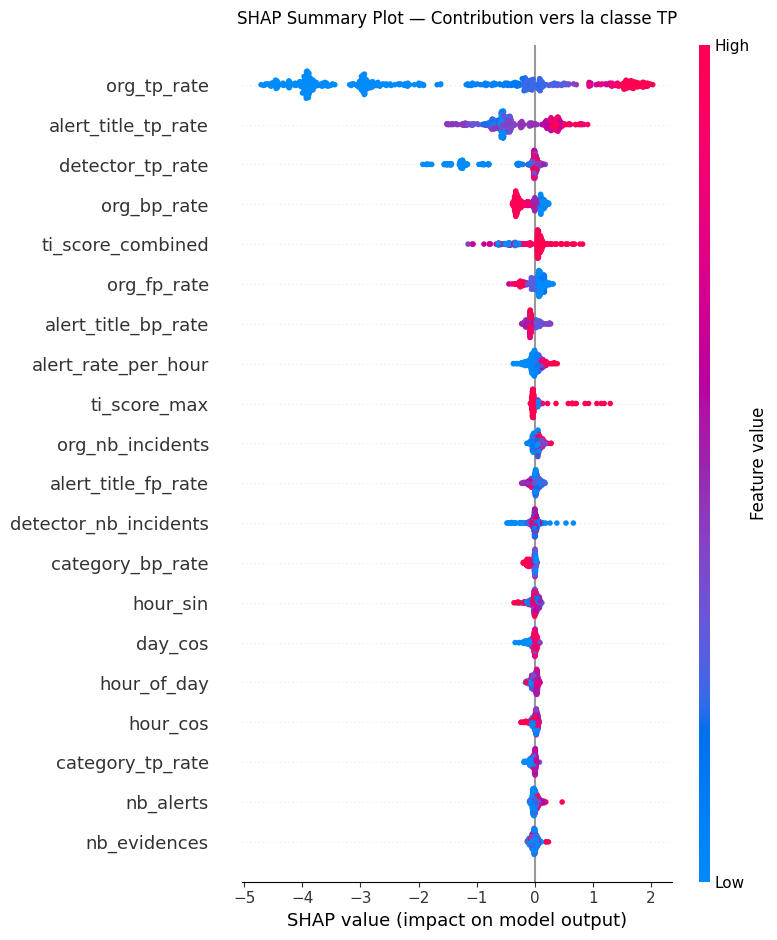

→ Points rouges = valeur élevée de la feature → pousse vers TP
  Points bleus = valeur faible → tire vers FP


In [17]:
# SHAP summary plot pour la classe TP (index 2)
shap_tp = shap_values[2]  # contributions vers la prédiction TP

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_tp, X_sample, feature_names=FEATURE_COLS,
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary Plot — Contribution vers la classe TP', pad=15)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_summary_tp.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ Points rouges = valeur élevée de la feature → pousse vers TP')
print('  Points bleus = valeur faible → tire vers FP')

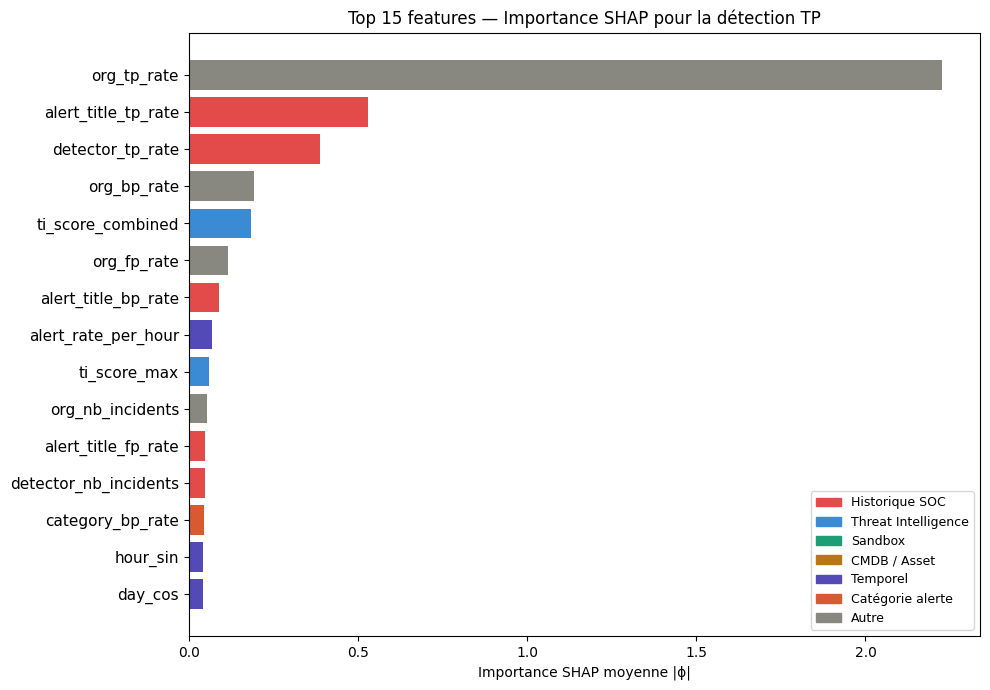

In [18]:
# Bar plot de l'importance SHAP moyenne (plus lisible pour la démo)
mean_abs_shap = np.abs(shap_tp).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_n = 15
top_shap = shap_importance.head(top_n)

# Couleurs par famille — ordre : du plus spécifique au plus générique
# pour éviter qu'un suffixe générique comme 'rate' capte des features d'autres familles
def get_family_color(feat_name):
    if any(k in feat_name for k in ['detector_', 'alert_title_']):
        return '#E24B4A'  # SOC historique
    elif any(k in feat_name for k in ['ti_', 'ip_', 'hash_', 'blocklist']):
        return '#3B8BD4'  # TI
    elif 'sandbox' in feat_name:
        return '#1D9E75'  # Sandbox
    elif 'asset' in feat_name:
        return '#BA7517'  # CMDB
    elif 'category_' in feat_name:
        return '#D85A30'  # Catégorie
    elif any(k in feat_name for k in ['hour', 'day', 'weekend', 'duration']):
        return '#534AB7'  # Temporel
    else:
        return '#888780'  # Autre

colors_shap = [get_family_color(f) for f in top_shap.index]
bars = ax.barh(range(top_n), top_shap.values, color=colors_shap)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_shap.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Importance SHAP moyenne |ϕ|')
ax.set_title('Top 15 features — Importance SHAP pour la détection TP')

legend_patches = [
    mpatches.Patch(color='#E24B4A', label='Historique SOC'),
    mpatches.Patch(color='#3B8BD4', label='Threat Intelligence'),
    mpatches.Patch(color='#1D9E75', label='Sandbox'),
    mpatches.Patch(color='#BA7517', label='CMDB / Asset'),
    mpatches.Patch(color='#534AB7', label='Temporel'),
    mpatches.Patch(color='#D85A30', label='Catégorie alerte'),
    mpatches.Patch(color='#888780', label='Autre'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_importance_bar.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. SHAP local — Explication d'un incident critique
**C'est ce que verra l'analyste N1 dans la démo.**

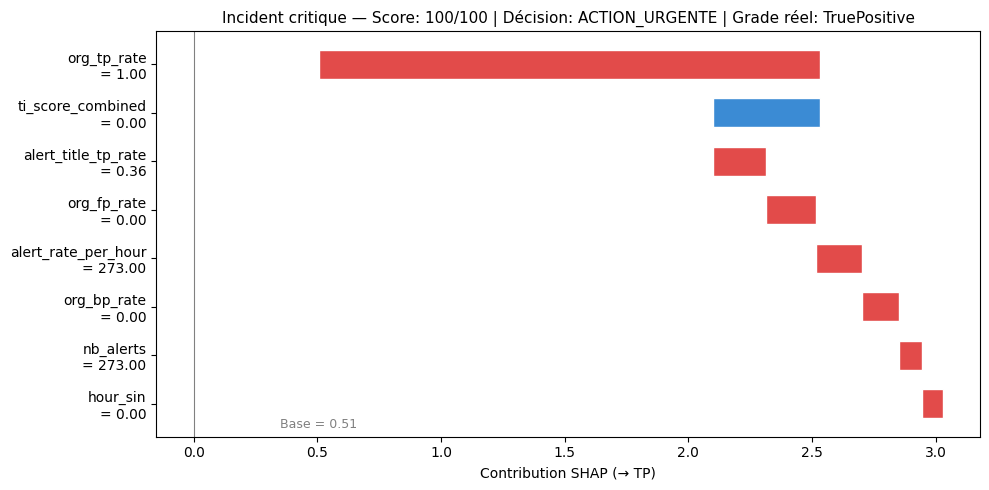

Top contributions pour cet incident :
org_tp_rate            2.0274
ti_score_combined     -0.4345
alert_title_tp_rate    0.2151
org_fp_rate            0.2029
alert_rate_per_hour    0.1831
org_bp_rate            0.1511
nb_alerts              0.0936
hour_sin               0.0829
dtype: float32


In [19]:
def explain_incident(incident_idx, title_prefix=''):
    """Génère le waterfall plot SHAP pour un incident donné (index positionnel dans df_sample)."""
    incident = df_sample.iloc[incident_idx]
    shap_local = shap_tp[incident_idx]  # contributions pour la classe TP

    # Top features contributives
    contrib = pd.Series(shap_local, index=FEATURE_COLS).sort_values(key=abs, ascending=False)
    top_contrib = contrib.head(8)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Waterfall chart manuel
    base_value = explainer.expected_value[2]
    cumulative = base_value
    bar_positions = []
    bar_heights = []
    bar_colors = []
    bar_labels = []

    for feat_name, contrib_val in top_contrib.items():
        feat_val = df_sample.iloc[incident_idx][feat_name]
        bar_positions.append(cumulative + contrib_val / 2)
        bar_heights.append(contrib_val)
        bar_colors.append('#E24B4A' if contrib_val > 0 else '#3B8BD4')
        bar_labels.append(f'{feat_name}\n= {feat_val:.2f}')
        cumulative += contrib_val

    # Affichage
    y_pos = range(len(bar_heights))
    bars = ax.barh(list(y_pos), bar_heights, left=[p - h/2 for p, h in zip(bar_positions, bar_heights)],
                   color=bar_colors, height=0.6, edgecolor='white')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(bar_labels, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('Contribution SHAP (→ TP)')

    score = incident['priority_score']
    decision = incident['decision_suggested']
    grade = incident.get('grade_reel_label', '?')
    ax.set_title(f'{title_prefix}Score: {score:.0f}/100 | Décision: {decision} | Grade réel: {grade}',
                 fontsize=11)

    # Valeur de base
    ax.text(base_value, len(bar_heights) - 0.5, f'Base = {base_value:.2f}',
            ha='center', color='gray', fontsize=9)

    plt.tight_layout()
    return fig, top_contrib

# Incident avec le score le plus élevé (indice positionnel direct)
max_score_idx = df_sample['priority_score'].values.argmax()
fig, contrib = explain_incident(max_score_idx, title_prefix='Incident critique — ')
plt.savefig(DATA_DIR / 'shap_waterfall_critique.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top contributions pour cet incident :')
print(contrib.round(4))

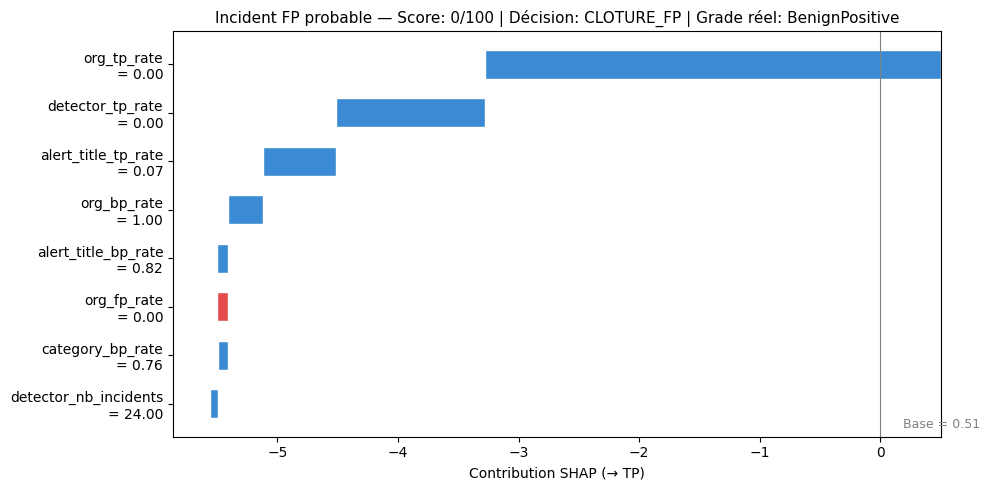


Contributions pour le FP probable :
org_tp_rate             -3.7833
detector_tp_rate        -1.2345
alert_title_tp_rate     -0.6112
org_bp_rate             -0.2889
alert_title_bp_rate     -0.0921
org_fp_rate              0.0919
category_bp_rate        -0.0765
detector_nb_incidents   -0.0740
dtype: float32


In [20]:
# Exemple : un incident FP probable pour contraste
fp_candidates = df_sample[df_sample['decision_suggested'] == 'CLOTURE_FP']
if len(fp_candidates) > 0:
    fp_pos = df_sample.index.get_loc(fp_candidates.index[0])  # index positionnel (reset_index garantit 0..N-1)
    fig, contrib_fp = explain_incident(fp_pos, title_prefix='Incident FP probable — ')
    plt.savefig(DATA_DIR / 'shap_waterfall_fp.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('\nContributions pour le FP probable :')
    print(contrib_fp.round(4))

## 4. Counterfactual — "Qu'est-ce qui aurait changé la décision ?"

Pour chaque incident, on identifie la feature la plus influente et on montre le seuil auquel la décision basculerait.

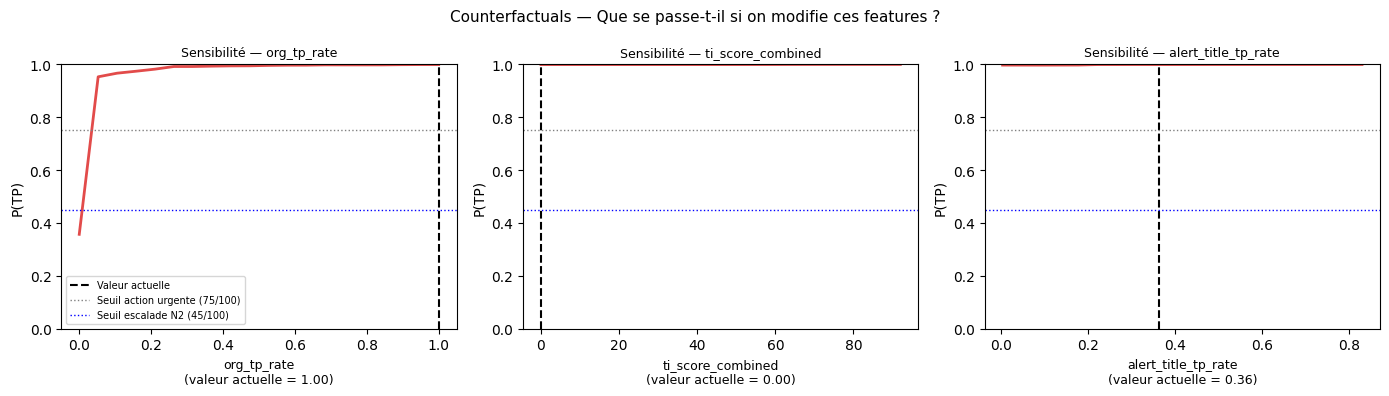

In [21]:
def compute_counterfactual(incident_idx, target_class=2, delta_steps=20):
    """
    Pour chaque feature dans le top 5, fait varier la valeur sur son étendue réelle
    et mesure l'impact sur la probabilité TP.
    """
    x_orig = X_sample[incident_idx].copy()
    shap_local = shap_tp[incident_idx]
    top_features = pd.Series(shap_local, index=FEATURE_COLS).abs().nlargest(5).index.tolist()

    results = []
    for feat_name in top_features:
        feat_idx = FEATURE_COLS.index(feat_name)
        orig_val = x_orig[feat_idx]

        # Bornes réelles observées dans les données (évite les valeurs hors-distribution)
        feat_min = X_sample[:, feat_idx].min()
        feat_max = X_sample[:, feat_idx].max()
        feat_range = np.linspace(feat_min, feat_max, delta_steps)

        scores = []
        for val in feat_range:
            x_mod = x_orig.copy()
            x_mod[feat_idx] = val
            prob_tp = xgb_model.predict_proba([x_mod])[0][2]
            scores.append(prob_tp)

        results.append({
            'feature': feat_name,
            'orig_val': orig_val,
            'orig_proba_tp': xgb_model.predict_proba([x_orig])[0][2],
            'feat_range': feat_range,
            'proba_tp_range': scores,
        })
    return results

# Counterfactual sur l'incident critique
cf_results = compute_counterfactual(max_score_idx)

# Seuils de probabilité TP (priority_score = prob_tp × 100 dans 03_ml_models)
SEUIL_ACTION_URGENTE_PROB = 0.75
SEUIL_ESCALADE_N2_PROB = 0.45

fig, axes = plt.subplots(1, min(3, len(cf_results)), figsize=(14, 4))
if len(cf_results) == 1:
    axes = [axes]

for i, (result, ax) in enumerate(zip(cf_results[:3], axes)):
    ax.plot(result['feat_range'], result['proba_tp_range'], color='#E24B4A', lw=2)
    ax.axvline(result['orig_val'], color='black', linestyle='--', lw=1.5, label='Valeur actuelle')
    ax.axhline(SEUIL_ACTION_URGENTE_PROB, color='gray', linestyle=':', lw=1, label='Seuil action urgente (75/100)')
    ax.axhline(SEUIL_ESCALADE_N2_PROB, color='blue', linestyle=':', lw=1, label='Seuil escalade N2 (45/100)')
    ax.set_xlabel(f'{result["feature"]}\n(valeur actuelle = {result["orig_val"]:.2f})', fontsize=9)
    ax.set_ylabel('P(TP)')
    ax.set_ylim(0, 1)
    ax.set_title(f'Sensibilité — {result["feature"][:30]}', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Counterfactuals — Que se passe-t-il si on modifie ces features ?', fontsize=11)
plt.tight_layout()
plt.savefig(DATA_DIR / 'counterfactuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Génération du texte d'explication pour la démo
Chaque incident reçoit une explication en langage naturel, prête à afficher dans Streamlit.

In [22]:
def generate_explanation_text(incident_row, shap_local, feature_names):
    """Génère un texte d'explication XAI pour l'analyste."""
    contrib = pd.Series(shap_local, index=feature_names).sort_values(key=abs, ascending=False)
    top_pos = contrib[contrib > 0].head(3)
    top_neg = contrib[contrib < 0].head(2)

    score = incident_row.get('priority_score', 0)
    decision = incident_row.get('decision_suggested', 'INVESTIGATION_N1')

    lines = []
    lines.append(f"**Score de priorisation : {score:.0f}/100** — Décision suggérée : {decision}")
    lines.append("")
    lines.append("**Raisons principales (↑ augmente le score) :**")
    for feat, val in top_pos.items():
        feat_val = incident_row[feat] if feat in incident_row.index else '?'
        formatted_val = f"{feat_val:.2f}" if isinstance(feat_val, float) else feat_val
        lines.append(f"  • {feat} = {formatted_val} → +{val:.3f}")

    if len(top_neg) > 0:
        lines.append("")
        lines.append("**Éléments qui réduisent le score (↓) :**")
        for feat, val in top_neg.items():
            feat_val = incident_row[feat] if feat in incident_row.index else '?'
            formatted_val = f"{feat_val:.2f}" if isinstance(feat_val, float) else feat_val
            lines.append(f"  • {feat} = {formatted_val} → {val:.3f}")

    return "\n".join(lines)

# Générer les explications pour tous les incidents de la démo
# i est l'indice positionnel direct grâce au reset_index(drop=True) effectué en cell 2
explanations = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    shap_local = shap_tp[i]
    text = generate_explanation_text(row, shap_local, FEATURE_COLS)
    explanations.append({'IncidentId': row['IncidentId'], 'explanation_text': text})

explanations_df = pd.DataFrame(explanations)
explanations_df.to_csv(DATA_DIR / 'explanations_sample.csv', index=False)
print(f'✅ explanations_sample.csv : {len(explanations_df):,} explications')

# Afficher un exemple
print('\nExemple d\'explication (incident critique) :')
print('-' * 50)
print(explanations_df.iloc[0]['explanation_text'])

✅ explanations_sample.csv : 500 explications

Exemple d'explication (incident critique) :
--------------------------------------------------
**Score de priorisation : 100/100** — Décision suggérée : ACTION_URGENTE

**Raisons principales (↑ augmente le score) :**
  • org_tp_rate = 0.93 → +1.857
  • nb_alerts = 7197 → +0.469
  • alert_rate_per_hour = 1000.00 → +0.385

**Éléments qui réduisent le score (↓) :**
  • ti_score_combined = 0.00 → -0.432
  • hash_nb_sources = 0.00 → -0.031


In [23]:
print('\n✅ Notebook XAI terminé. Fichiers générés :')
print('  data/shap_values_sample.pkl')
print('  data/explanations_sample.csv')
print('  data/shap_summary_tp.png')
print('  data/shap_importance_bar.png')
print('  data/shap_waterfall_critique.png')
print('  data/shap_waterfall_fp.png')
print('  data/counterfactuals.png')
print('\n→ Prochaine étape : streamlit run 05_demo_app.py')


✅ Notebook XAI terminé. Fichiers générés :
  data/shap_values_sample.pkl
  data/explanations_sample.csv
  data/shap_summary_tp.png
  data/shap_importance_bar.png
  data/shap_waterfall_critique.png
  data/shap_waterfall_fp.png
  data/counterfactuals.png

→ Prochaine étape : streamlit run 05_demo_app.py
